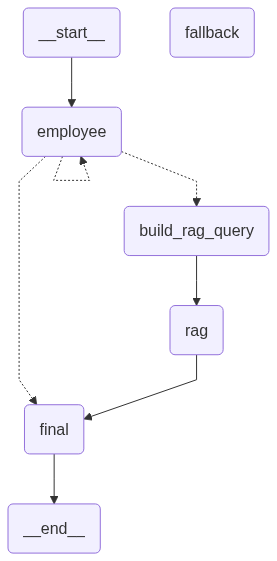


Invoke 1: 测试硬路由逻辑 (E1001)
[运行轨迹] 1. 进入 employee_node，提取工号并查库...
[运行轨迹] 3. 进入 build_rag_query_node，构建查询词...
[运行轨迹] 4. 进入 rag_node，正在检索: 试用期员工年假规定
[运行轨迹] 5. 进入 final_node，大模型开始整合回答...

【最终大模型回复】:
================================== Ai Message ==================================

[{'data': 'gAAAAABqftiZlLCtd5LtEVj2yTfZcsyLddYHyw3dnonigeMNZVQk5Y1Nt5mciQXT--CnrJbKpmCeki8Z2s64VMwLFQF6tQuk-EibSdwvCG8KmlK7zxTc_RXWNwx3xkUQElHCxXqL7eJiqErk5utcu1QuOC9CziimdQpWXxC5cGVwdtJ0NywqaCAJ52L-pyxfQfy9Dhy6dRnKiVpXk_8-89bOSnUNktORH0F66kEicECOYLuc9m7kJDKYtPXc22YiBP_zXy3cPOwA00hWcpvrOCTOs5D2DmbRldD-ybEbDGtt1pqswBFxoYpAL4f5x9p7fMJ6inx_nOgrJu-Dk4cNlmwUgUht9N3HQ2ZPy43awKMDFVhJteubsyg7UsCPhWCy0MQc59vEWC3hywQUC-OUJ_LKLuien1mCaVzXTrcXGILW32lovyAz1DxapbGkK5bKa9oiSWzC5ePT8sa0pB8mVq895rInXfGKMn_3OChLOw6-f6535YUzRkgxA87MKxYi58WH4OABNGUmKq4zHBnxwHNHZgloG-7zi1DWryTlutWmgdcDdu3f5gT6y-z4Hy-oo3wykFPiHme_tpEjqcYY_dZlcKPZgxvEGJ62NwdFVVaYTjMBtVfxlYSALS9Ha_2d4PzG7KTbbBpfjl4E5zsK1_iTXLwx16PLnkvZWAC-AdBw49C8jw9OcfMlxlOHsNUrFiRje9-Q

In [6]:
import os
import re
from typing import Literal
from typing_extensions import TypedDict, Annotated
from IPython.display import Image, display

from langchain.chat_models import init_chat_model
from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings
from langchain.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langgraph.graph import START, END, StateGraph

# ==========================================
# 1. 鉴权与模型初始化
# ==========================================
if "ANTHROPIC_AUTH_TOKEN" in os.environ and "ANTHROPIC_API_KEY" not in os.environ:
    os.environ["ANTHROPIC_API_KEY"] = os.environ["ANTHROPIC_AUTH_TOKEN"]

model = init_chat_model(
    "claude-sonnet-5",
    model_provider="anthropic",
    temperature=0
)


# ==========================================
# 2. 准备 Document 和 向量库
# ==========================================
documents = [
    Document(page_content="试用期员工不享受带薪年假。", metadata={"source": "员工手册2026", "page": 23, "status": "active", "year": 2026}),
    Document(page_content="正式员工每年享有10天带薪年假。", metadata={"source": "员工手册2026", "page": 23, "status": "active", "year": 2026}),
    Document(page_content="单笔报销超过5000元，需要部门负责人审批。", metadata={"source": "财务制度2026", "page": 12, "status": "active", "year": 2026}),
    Document(page_content="试用期员工享有3天带薪年假。", metadata={"source": "员工手册2024", "page": 20, "status": "archived", "year": 2024})
]

embeddings = OpenAIEmbeddings(
    model="qwen3.7-text-embedding", 
    openai_api_base="https://llm-v4mqkweosjvc0she.cn-beijing.maas.aliyuncs.com/compatible-mode/v1",
    check_embedding_ctx_length=False, 
)

vector_store = InMemoryVectorStore(embedding=embeddings)
vector_store.add_documents(documents)

SCORE_THRESHOLD = 0.7

def retrieve_company_knowledge(query: str) -> dict:
    results = vector_store.similarity_search_with_score(
        query, k=3, 
        filter=lambda doc: doc.metadata.get("status") == "active" and doc.metadata.get("year") == 2026
    )
    valid_results = [(doc, score) for doc, score in results if score >= SCORE_THRESHOLD]
    
    if not valid_results:
        return {"status": "NO_RELEVANT_KNOWLEDGE", "results": []}
    return {
        "status": "OK",
        "results": [
            {
                "content": doc.page_content, 
                "score": score, 
                "source": doc.metadata.get("source"),
                "year": doc.metadata.get("year")
            }
            for doc, score in valid_results
        ]
    }

EMPLOYEE_DB = {
    "E1001": {"name": "张三", "status": "probation", "annual_leave_balance": 0, "department": "研发部"},
    "E1002": {"name": "李四", "status": "regular", "annual_leave_balance": 7, "department": "财务部"},
}

# ==========================================
# 3. 定义 State 状态字典
# ==========================================
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    employee_id: str | None
    employee: dict | None
    rag_query: str | None
    knowledge: dict | None
    status: str
    error: str | None
    retry_count: int

# ==========================================
# 4. 定义 Nodes 节点
# ==========================================

def query_employee(employee_id: str, retry_count: int):
    if employee_id == "E500":
        raise ConnectionError("503 Service Unavailable")

    if employee_id == "E401":
        raise PermissionError("401 Unauthorized")

    return EMPLOYEE_DB.get(employee_id)
    

def employee_node(state: AgentState):
    print("[运行轨迹] 1. 进入 employee_node，提取工号并查库...")
    
    # 【修改点2】从用户的提问中动态提取工号 (例如 "E1001")
    user_message = state["messages"][-1].content
    match = re.search(r'E\d{4}', user_message)
    employee_id = match.group(0) if match else None

    try:
        employee = query_employee(
            employee_id,
            state.get("retry_count", 0)
        )

        if employee is None:
            return {
                "employee": None,
                "status": "not_found",
                "error": None
            }

        return {
            "employee": employee,
            "status": "success",
            "error": None
        }

    except ConnectionError as e:
        return {
            "status": "retryable_error",
            "error": str(e),
            "retry_count":
                state.get("retry_count", 0) + 1
        }

    except PermissionError as e:
        return {
            "status": "fatal_error",
            "error": str(e)
        }

EMPLOYEE_CACHE = {
    "E500": {
        "name": "缓存员工",
        "status": "probation",
        "annual_leave_balance": 0,
        "department": "研发部"
    }
}

MAX_RETRIES = 3

def route_after_employee(state: AgentState):

    status = state["status"]

    if status == "success":
        return "build_rag_query"

    if status == "not_found":
        return "final"

    if status == "retryable_error":
        if state["retry_count"] < MAX_RETRIES:
            return "employee"

        return "fallback"

    if status == "fatal_error":
        return "final"

    return "final"

def build_rag_query_node(state: AgentState):
    print("[运行轨迹] 3. 进入 build_rag_query_node，构建查询词...")
    employee = state["employee"]
    status = employee["status"]
    
    if status == "probation":
        query = "试用期员工年假规定"
    else:
        query = "正式员工年假规定"
        
    return {"rag_query": query}

def rag_node(state: AgentState):
    print(f"[运行轨迹] 4. 进入 rag_node，正在检索: {state['rag_query']}")
    result = retrieve_company_knowledge(state["rag_query"])
    return {"knowledge": result}

def fallback_node(state: AgentState):
    employee = EMPLOYEE_CACHE.get(
        state["employee_id"]
    )
    if employee is None:
        return {
            "employee": None,
            "status": "fallback_failed",
            "error": "缓存中也没有员工数据"
        }
    return {
        "employee": employee,
        "status": "fallback_success",
        "error": None
    }
    
def route_after_fallback(state: AgentState):
    if state["status"] == "fallback_success":
        return "build_rag_query"
    return "final"

def final_node(state: AgentState):
    print("[运行轨迹] 5. 进入 final_node，大模型开始整合回答...")
    employee = state.get("employee")
    knowledge = state.get("knowledge")

    # 【修改点3】重写 final_node。必须将信息组装给大模型，并返回包含 AIMessage 的字典
    if not employee:
        return {"messages": [AIMessage(content="抱歉，系统中未找到该员工的信息，无法核实年假情况。")]}

    # 组装硬性 Prompt，大模型只负责最后的话术润色
    sys_prompt = f"""
    你是公司HR助手。请根据系统查询到的确凿信息回答用户问题。
    
    【员工实时信息】：
    姓名：{employee['name']}
    状态：{'试用期' if employee['status'] == 'probation' else '正式员工'}
    部门：{employee['department']}
    当前年假余额：{employee['annual_leave_balance']}天
    
    【公司制度依据】：
    {knowledge['results'][0]['content'] if knowledge and knowledge.get('status') == 'OK' else '未找到相关制度'}
    
    要求：语气专业客观，必须同时结合员工身份和公司制度给出明确解释。
    """
    
    response = model.invoke([SystemMessage(content=sys_prompt)] + state["messages"])
    
    return {"messages": [response]}

# ==========================================
# 5. 构建图 Graph (组装流水线)
# ==========================================
builder = StateGraph(AgentState)

builder.add_node("employee", employee_node)
builder.add_node("build_rag_query", build_rag_query_node)
builder.add_node("rag", rag_node)  
builder.add_node("final", final_node)
builder.add_node("fallback",fallback_node)

builder.add_edge(START, "employee")
builder.add_conditional_edges(
    "employee",
    route_after_employee,
    {
        "build_rag_query": "build_rag_query",
        "final": "final",
        "employee":"employee",
    }
)

# 【修改点4】补全缺失的连线
builder.add_edge("build_rag_query", "rag")  # 构建完查询词，连到RAG
builder.add_edge("rag", "final")            # RAG查完，连到Final
builder.add_edge("final", END)              # Final说完，结束

graph = builder.compile()

# 显示流程图
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

# ==========================================
# 6. 运行测试
# ==========================================
print("\n" + "="*50)
print("Invoke 1: 测试硬路由逻辑 (E1001)")
print("="*50)
result = graph.invoke({
    "messages": [
        HumanMessage(content="E1001为什么没有年假？")
    ]
})

print("\n【最终大模型回复】:")
result["messages"][-1].pretty_print()



print("\n" + "="*50)
print("Invoke 2: 测试硬路由逻辑 (E9999)")
print("="*50)
result = graph.invoke({
    "messages": [
        HumanMessage(
            content="E9999为什么没有年假？"
        )
    ]
})

print("\n【最终大模型回复】:")
result["messages"][-1].pretty_print()


print("\n" + "="*50)
print("Invoke 3: E401为什么没有年假？")
print("="*50)
result = graph.invoke({
    "messages": [
        HumanMessage(
            content="E401为什么没有年假？"
        )
    ]
})

print("\n【最终大模型回复】:")
result["messages"][-1].pretty_print()


print("\n" + "="*50)
print("Invoke 4: E500为什么没有年假？")
print("="*50)
result = graph.invoke({
    "messages": [
        HumanMessage(
            content="E500为什么没有年假？"
        )
    ]
})

print("\n【最终大模型回复】:")
result["messages"][-1].pretty_print()